In [ ]:
import DALI as dali_code
from tqdm import tqdm
import os
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.constrained_layout.use'] = True
from collections import Counter
import numpy as np
import rootutils

root = rootutils.setup_root(
    search_from=".",
    indicator=".project-root",
    pythonpath=True
)

In [ ]:
dali_data_path = os.path.join("../../data/DALI/DALI_v2.0/annot_tismir")
dali_data = dali_code.get_the_DALI_dataset(dali_data_path, skip=[], keep=[])

/home/ids/chawang/miniconda3/envs/mlm_new/lib/python3.12/site-packages/DALI/utilities.py:110: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  output = pickle.load(f)


In [ ]:
df = pd.read_csv("../../data/DALI_English_songs.csv")
song_ids = df[df['split'] == 'development']['English_song_ids'].values

In [8]:
genres = []
no_genre_count = 0
for id in tqdm(song_ids):
    entry = dali_data[id]
    if 'genres' not in entry.info['metadata'] or entry.info['metadata']['genres'] == '' or entry.info['metadata']['genres'] == []:
        no_genre_count += 1
        continue
    else:
        genre = entry.info['metadata']['genres']
        genres.append(genre[0] if isinstance(genre, list) else genre)

100%|██████████| 5764/5764 [00:00<00:00, 408640.14it/s]


In [9]:
for k in range(10, 20):
    entry = dali_data[song_ids[k]]
    if 'genres' not in entry.info['metadata'] or entry.info['metadata']['genres'] == '' or entry.info['metadata']['genres'] == []:
        continue
    else:
        genre = entry.info['metadata']['genres']
        print(genre)

['Rock']
['Pop']
['R&B']
['Alternative', 'Rock', 'Rock Indé/Pop Rock']
['R&B']
['Rock']
['Metal']
['Rap/Hip Hop', 'R&B', 'Disco', 'Soul']
['Rock']
['Pop', 'Rock', 'Metal']


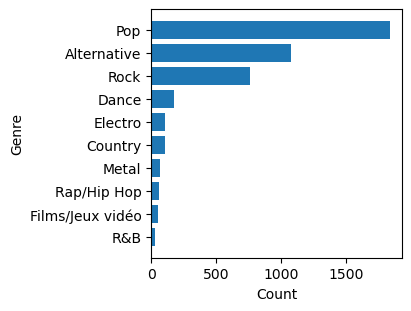

In [ ]:
# plot genre distribution from most common to least common, only plot top 10 genres
# y axis is genre name, x axis is genre count
genre_counts = Counter(genres)
most_common_genres = genre_counts.most_common(10)
genre_names = [genre for genre, count in most_common_genres]
genre_values = [count for genre, count in most_common_genres]
plt.figure(figsize=(4, 3))
plt.barh(genre_names, genre_values)
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.show()

## Length distribution

In [40]:
seg_lnums = [4, 8, 12]
dev_len_relative = {k: [] for k in seg_lnums}

for num in seg_lnums:
    len_file = np.load(f"../outputs/Seg{num}_len_note_syl.npy", allow_pickle=True)
    dev_len = np.array(len_file.item()["train"] + len_file.item()["val"])
    dev_len_relative[num] = dev_len[:,0] / dev_len[:,1]

In [41]:
Seg4_train = np.array(np.load(f"../outputs/Seg4_len_note_syl.npy", allow_pickle=True).item()["train"])
Seg4_val = np.array(np.load(f"../outputs/Seg4_len_note_syl.npy", allow_pickle=True).item()["val"])
Seg4_test = np.array(np.load(f"../outputs/Seg4_len_note_syl.npy", allow_pickle=True).item()["test"])

Seg8_train = np.array(np.load(f"../outputs/Seg8_len_note_syl.npy", allow_pickle=True).item()["train"])
Seg8_val = np.array(np.load(f"../outputs/Seg8_len_note_syl.npy", allow_pickle=True).item()["val"])
Seg8_test = np.array(np.load(f"../outputs/Seg8_len_note_syl.npy", allow_pickle=True).item()["test"])

Seg12_train = np.array(np.load(f"../outputs/Seg12_len_note_syl.npy", allow_pickle=True).item()["train"])
Seg12_val = np.array(np.load(f"../outputs/Seg12_len_note_syl.npy", allow_pickle=True).item()["val"])
Seg12_test = np.array(np.load(f"../outputs/Seg12_len_note_syl.npy", allow_pickle=True).item()["test"])

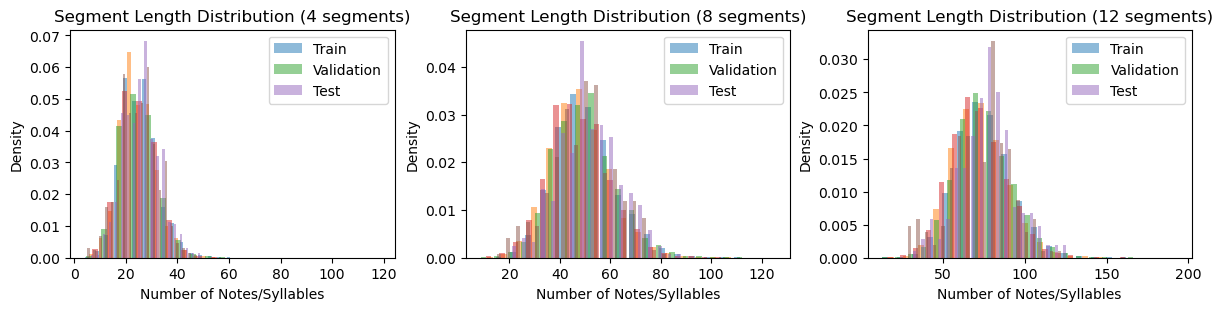

In [22]:
# segment length distribution plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(Seg4_train, bins=20, alpha=0.5, label='Train', density=True)
plt.hist(Seg4_val, bins=20, alpha=0.5, label='Validation', density=True)
plt.hist(Seg4_test, bins=20, alpha=0.5, label='Test', density=True)
plt.title('Segment Length Distribution (4 segments)')
plt.xlabel('Number of Notes/Syllables')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(Seg8_train, bins=20, alpha=0.5, label='Train', density=True)
plt.hist(Seg8_val, bins=20, alpha=0.5, label='Validation', density=True)
plt.hist(Seg8_test, bins=20, alpha=0.5, label='Test', density=True)
plt.title('Segment Length Distribution (8 segments)')
plt.xlabel('Number of Notes/Syllables')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(Seg12_train, bins=20, alpha=0.5, label='Train', density=True)
plt.hist(Seg12_val, bins=20, alpha=0.5, label='Validation', density=True)
plt.hist(Seg12_test, bins=20, alpha=0.5, label='Test', density=True)
plt.title('Segment Length Distribution (12 segments)')
plt.xlabel('Number of Notes/Syllables')
plt.ylabel('Density')
plt.legend()

In [27]:
seg_lnums = [4, 8, 12]
dev_len_relative_filtered = {k: [] for k in seg_lnums}

for num in seg_lnums:
    len_file = np.load(f"../outputs/Seg{num}_len_note_syl.npy", allow_pickle=True)
    dev_len = np.array(len_file.item()["train"] + len_file.item()["val"])
    dev_len_relative_filtered[num] = dev_len[:,0] / dev_len[:,1]

In [28]:
Seg4_train_filtered = np.array(np.load(f"../outputs/Seg4_len_note_syl_filtered.npy", allow_pickle=True).item()["train"])
Seg4_val_filtered = np.array(np.load(f"../outputs/Seg4_len_note_syl_filtered.npy", allow_pickle=True).item()["val"])
Seg4_test_filtered = np.array(np.load(f"../outputs/Seg4_len_note_syl_filtered.npy", allow_pickle=True).item()["test"])

Seg8_train_filtered = np.array(np.load(f"../outputs/Seg8_len_note_syl_filtered.npy", allow_pickle=True).item()["train"])
Seg8_val_filtered = np.array(np.load(f"../outputs/Seg8_len_note_syl_filtered.npy", allow_pickle=True).item()["val"])
Seg8_test_filtered = np.array(np.load(f"../outputs/Seg8_len_note_syl_filtered.npy", allow_pickle=True).item()["test"])

Seg12_train_filtered = np.array(np.load(f"../outputs/Seg12_len_note_syl_filtered.npy", allow_pickle=True).item()["train"])
Seg12_val_filtered = np.array(np.load(f"../outputs/Seg12_len_note_syl_filtered.npy", allow_pickle=True).item()["val"])
Seg12_test_filtered = np.array(np.load(f"../outputs/Seg12_len_note_syl_filtered.npy", allow_pickle=True).item()["test"])

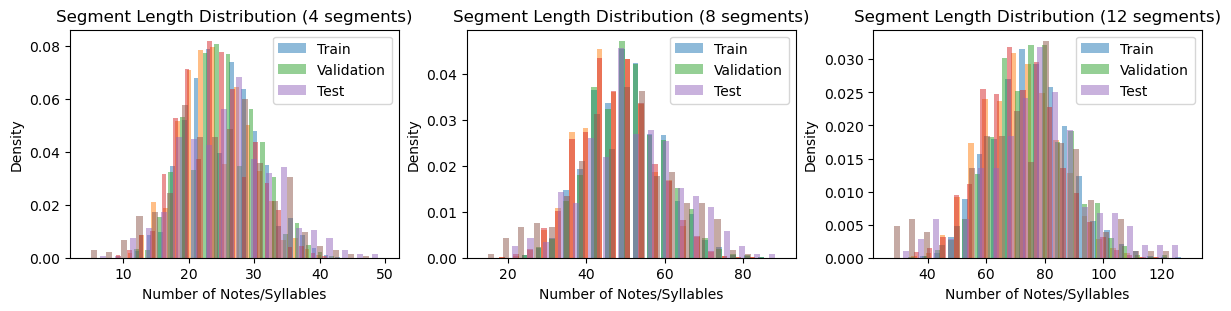

In [30]:
# segment length distribution plot
plt.figure(figsize=(12, 3))
plt.subplot(1, 3, 1)
plt.hist(Seg4_train_filtered, bins=20, alpha=0.5, label='Train', density=True)
plt.hist(Seg4_val_filtered, bins=20, alpha=0.5, label='Validation', density=True)
plt.hist(Seg4_test_filtered, bins=20, alpha=0.5, label='Test', density=True)
plt.title('Segment Length Distribution (4 segments)')
plt.xlabel('Number of Notes/Syllables')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(Seg8_train_filtered, bins=20, alpha=0.5, label='Train', density=True)
plt.hist(Seg8_val_filtered, bins=20, alpha=0.5, label='Validation', density=True)
plt.hist(Seg8_test_filtered, bins=20, alpha=0.5, label='Test', density=True)
plt.title('Segment Length Distribution (8 segments)')
plt.xlabel('Number of Notes/Syllables')
plt.ylabel('Density')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(Seg12_train_filtered, bins=20, alpha=0.5, label='Train', density=True)
plt.hist(Seg12_val_filtered, bins=20, alpha=0.5, label='Validation', density=True)
plt.hist(Seg12_test_filtered, bins=20, alpha=0.5, label='Test', density=True)
plt.title('Segment Length Distribution (12 segments)')
plt.xlabel('Number of Notes/Syllables')
plt.ylabel('Density')
plt.legend()

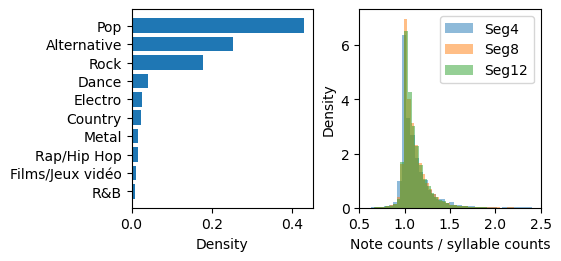

In [ ]:
plt.figure(figsize=(5.5, 2.5))

plt.subplot(1, 2, 1)
genre_counts = Counter(genres)
most_common_genres = genre_counts.most_common(10)
genre_names = [genre for genre, count in most_common_genres]
genre_values = [count for genre, count in most_common_genres]
plt.barh(genre_names, [count / sum(genre_values) for count in genre_values])
plt.xlabel('Density')
plt.gca().invert_yaxis()

plt.subplot(1, 2, 2)
for num in seg_lnums:
    plt.hist(dev_len_relative[num], bins=350, alpha=0.5, label=f"Seg{num}", density=True)
plt.xlabel('Note counts / syllable counts')
plt.ylabel('Density')
plt.xlim(0.5, 2.5)
plt.legend()

plt.savefig('../outputs/Seg_dev_lenDiff_genres.pdf')

## Remaining percentage after truncating

Dataset size before, after only filtering out rare line length, after filter out also segments with rare note-syl vectors:
- Seg 4 : 66800, 59994, 41558
- Seg 8 : 35133, 31179, 20804
- Seg 12 : 22948, 20295, 13168

In [3]:
print("Remaining percentage after line length filtering:")
print(f"Seg 4: {round(59994 / 66800 * 100, 1)}")
print(f"Seg 8: {round(31179 / 35133 * 100, 1)}")
print(f"Seg 12: {round(20295 / 22948 * 100, 1)}")

Remaining percentage after line length filtering:
Seg 4: 89.8
Seg 8: 88.7
Seg 12: 88.4


In [4]:
print("Remaining percentage after all filtering:")
print(f"Seg 4: {round(41558 / 66800 * 100, 1)}")
print(f"Seg 8: {round(20804 / 35133 * 100, 1)}")
print(f"Seg 12: {round(13168 / 22948 * 100, 1)}")

Remaining percentage after all filtering:
Seg 4: 62.2
Seg 8: 59.2
Seg 12: 57.4
